## Import

In [67]:
import pandas as pd
import numpy as np

In [68]:
target_column = ['First_Round_Interviews','Second_Round_Interviews','Offer_Received']

## Read the Data
Loads the raw CSV into a DataFrame and previews key columns with high missing rates
(Accepted_Offer, Role_Relevance, Company_Size_Offered, Time_to_Offer_Days)
to motivate the cleaning decisions in the next section.

Prerequisites : pandas and numpy imported (Initial Work)

Produces      : df


In [69]:
df=pd.read_csv('../data/job_search_platform_efficacy_100k.csv')
df.head(20)

,Student_ID,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Company_Size_Offered,Role_Relevance,Accepted_Offer
0,STU_000001,Mid-tier,Medium,West,Healthcare,2.81,3,2,6,LinkedIn,1,9,2,2,1,46.0,59785.0,Mid-Size,9.0,1.0
1,STU_000002,Lower-tier,Medium,Northeast,STEM,2.61,1,1,6,Handshake,1,5,1,0,0,NaN,NaN,NaN,NaN,NaN
2,STU_000003,Lower-tier,Medium,Midwest,STEM,3.53,3,2,2,Handshake,5,34,3,1,0,NaN,NaN,NaN,NaN,NaN
3,STU_000004,Mid-tier,Medium,Midwest,Business,2.73,0,2,1,Handshake,2,10,0,0,0,NaN,NaN,NaN,NaN,NaN
4,STU_000005,Mid-tier,Medium,South,Business,4.00,1,0,1,Indeed,5,65,0,0,0,NaN,NaN,NaN,NaN,NaN
5,STU_000006,Mid-tier,Large,Midwest,Business,4.00,0,4,1,Handshake,2,6,0,0,0,NaN,NaN,NaN,NaN,NaN
6,STU_000007,Top-tier,Large,West,STEM,3.28,2,0,7,Handshake,10,20,0,0,0,NaN,NaN,NaN,NaN,NaN
7,STU_000008,Lower-tier,Large,West,Business,2.62,2,3,7,LinkedIn,10,76,3,0,0,NaN,NaN,NaN,NaN,NaN
8,STU_000009,Mid-tier,Medium,Northeast,STEM,3.01,0,3,2,Handshake,7,19,2,1,1,31.0,69910.0,Mid-Size,7.0,1.0
9,STU_000010,Lower-tier,Medium,West,STEM,3.22,2,1,1,Indeed,6,67,2,1,1,38.0,73669.0,Startup,1.0,1.0


In [70]:
print(df.Accepted_Offer.value_counts(dropna=False))
print(df.Role_Relevance.value_counts(dropna=False))
print(df.Company_Size_Offered.value_counts(dropna=False))
print(df.Time_to_Offer_Days.value_counts(dropna=False))

Accepted_Offer
NaN    65771
1.0    27445
0.0     6784
Name: count, dtype: int64
Role_Relevance
NaN     65771
8.0      6500
7.0      5921
6.0      5038
9.0      4778
10.0     3744
5.0      3307
4.0      2115
3.0      1290
2.0       778
1.0       758
Name: count, dtype: int64
Company_Size_Offered
NaN           65771
Enterprise    13908
Mid-Size      13623
Startup        6698
Name: count, dtype: int64
Time_to_Offer_Days
NaN     65771
41.0      833
43.0      822
33.0      813
32.0      811
        ...  
14.0      201
19.0      200
16.0      193
17.0      184
18.0      183
Name: count, Length: 77, dtype: int64


## Data Cleaning
```
Drops columns that are either identifiers (Student_ID) or would cause data leakage /
have >60% missing values (Offer_Salary, Company_Size_Offered, Role_Relevance,
Accepted_Offer, Time_to_Offer_Days). Checks for duplicate rows.

Prerequisites : df  (Read the Data)
Produces      : df_clean
```

In [71]:
df_clean = df.drop(columns=['Student_ID','Offer_Salary','Company_Size_Offered','Role_Relevance','Accepted_Offer','Time_to_Offer_Days'])
df_clean.head(20)


,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received
0,Mid-tier,Medium,West,Healthcare,2.81,3,2,6,LinkedIn,1,9,2,2,1
1,Lower-tier,Medium,Northeast,STEM,2.61,1,1,6,Handshake,1,5,1,0,0
2,Lower-tier,Medium,Midwest,STEM,3.53,3,2,2,Handshake,5,34,3,1,0
3,Mid-tier,Medium,Midwest,Business,2.73,0,2,1,Handshake,2,10,0,0,0
4,Mid-tier,Medium,South,Business,4.00,1,0,1,Indeed,5,65,0,0,0
5,Mid-tier,Large,Midwest,Business,4.00,0,4,1,Handshake,2,6,0,0,0
6,Top-tier,Large,West,STEM,3.28,2,0,7,Handshake,10,20,0,0,0
7,Lower-tier,Large,West,Business,2.62,2,3,7,LinkedIn,10,76,3,0,0
8,Mid-tier,Medium,Northeast,STEM,3.01,0,3,2,Handshake,7,19,2,1,1
9,Lower-tier,Medium,West,STEM,3.22,2,1,1,Indeed,6,67,2,1,1


In [72]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   University_Rating            100000 non-null  object 
 1   School_Size                  100000 non-null  object 
 2   Region                       100000 non-null  object 
 3   Major_Category               100000 non-null  object 
 4   GPA                          100000 non-null  float64
 5   Prior_Internships            100000 non-null  int64  
 6   Extra_Curricular_Activities  100000 non-null  int64  
 7   Networking_Events_Attended   100000 non-null  int64  
 8   Primary_Search_Platform      100000 non-null  object 
 9   Months_Searching             100000 non-null  int64  
 10  Applications_Submitted       100000 non-null  int64  
 11  First_Round_Interviews       100000 non-null  int64  
 12  Second_Round_Interviews      100000 non-null  int64  
 13  

In [73]:
print(df.duplicated().sum())
df_clean.describe()

0


,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000
mean,3.196631,1.19697,2.003990,2.998600,6.499680,53.727620,2.16766,1.011640,0.342290
std,0.392370,1.12192,1.413709,1.734494,3.443719,45.004663,1.91176,1.138507,0.474478
min,2.000000,0.00000,0.000000,0.000000,1.000000,5.000000,0.00000,0.000000,0.000000
25%,2.930000,0.00000,1.000000,2.000000,4.000000,19.000000,1.00000,0.000000,0.000000
50%,3.200000,1.00000,2.000000,3.000000,6.000000,42.000000,2.00000,1.000000,0.000000
75%,3.470000,2.00000,3.000000,4.000000,9.000000,75.000000,3.00000,2.000000,1.000000
max,4.000000,5.00000,11.000000,14.000000,12.000000,300.000000,21.00000,12.000000,1.000000


## Preprocessing
```
Defines the binary target (Offer_Received 0/1), separates numeric and categorical
features, one-hot encodes categoricals, splits into train/test sets (80/20, stratified),
and standardizes numeric columns using StandardScaler fit on training data only.
Saves a snapshot before feature engineering as X_train_base / X_test_base.

Note: A 4-class target (no interview / 1st round / 2nd round / offer) was explored
but abandoned — see commented-out cells. Binary classification was adopted because
class overlap in intermediate stages (class 1 vs class 2) made 4-class accuracy
plateau at ~45% across all models.

Prerequisites : df_clean  (Data Cleaning)
Produces      : X_train, X_test, y_train, y_test       [feature-engineered, updated later]
                X_train_base, X_test_base               [pre-engineering snapshot]
                X_numeric_columns, scaler
```

### Create a 4-class Target Variable

> Created by Yueqiao\
> Modified by Mingkun Fu on 5/9

This will make it to a classification problem

In [74]:
#def create_target(row):
#    if row['Offer_Received'] == 1:
#        return 3  # Got Offer
#    elif row['Second_Round_Interviews'] > 0:
#        return 2  # Second Round Interview but No Offer
#    elif row['First_Round_Interviews'] > 0:
#        return 1  # Interview but No Offer
#    else:
#        return 0  # No Interview
#    
#def return_target(num):
#    if num == 3:
#        return 'Got Offer'
#    elif num == 2:
#        return 'Second Round Interview but No Offer'
#    elif num == 1:
#        return 'Interview but No Offer'
#    else:
#        return 'No Interview'
#
#df_clean['application_result'] = df_clean.apply(create_target, axis=1)
#df_clean.drop(columns=target_column, inplace=True)
#df_clean.head(2)
#
#y = df_clean['application_result']
#X = df_clean.drop(columns=['application_result'])
#
#print("The distribution of the target variable:")
#print(y.value_counts())

### explore Candidates who have 2nd Interview

In [75]:
df_clean_i=df_clean[df_clean['Second_Round_Interviews']>0]
df_clean_i

,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received
0,Mid-tier,Medium,West,Healthcare,2.81,3,2,6,LinkedIn,1,9,2,2,1
2,Lower-tier,Medium,Midwest,STEM,3.53,3,2,2,Handshake,5,34,3,1,0
8,Mid-tier,Medium,Northeast,STEM,3.01,0,3,2,Handshake,7,19,2,1,1
9,Lower-tier,Medium,West,STEM,3.22,2,1,1,Indeed,6,67,2,1,1
10,Top-tier,Small,Midwest,STEM,3.59,2,1,3,LinkedIn,5,31,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99993,Mid-tier,Small,West,Business,3.52,4,2,2,LinkedIn,10,110,4,4,1
99995,Lower-tier,Large,Northeast,STEM,3.61,3,1,1,Handshake,3,15,2,1,1
99997,Lower-tier,Small,Northeast,Business,3.38,4,2,2,Indeed,4,60,2,1,0
99998,Mid-tier,Large,Midwest,Business,3.20,2,0,0,LinkedIn,7,39,4,1,0


In [76]:
y=df_clean_i['Offer_Received']
X=df_clean_i.drop(columns=['Offer_Received','First_Round_Interviews','Second_Round_Interviews'])
print("The distribution of the target variable:")
print(y.value_counts())

The distribution of the target variable:
Offer_Received
1    34229
0    24543
Name: count, dtype: int64


### Divide to Numberic and Categorical
> Created by Mingkun on Apr 29;\
> Modified by Yueqiao on Apr 30

In [77]:
X_numeric = X.select_dtypes(include=[np.number])
print("Numeric columns:")
X_numeric_columns = X_numeric.columns
print(X_numeric.columns)
X_numeric.head(1)

Numeric columns:
Index(['GPA', 'Prior_Internships', 'Extra_Curricular_Activities',
       'Networking_Events_Attended', 'Months_Searching',
       'Applications_Submitted'],
      dtype='object')


,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted
0,2.81,3,2,6,1,9


In [78]:
X_categorical = X.select_dtypes(include=['object', 'string'])
print("\nCategorical columns:")
print(X_categorical.columns)
X_categorical.head(1)


Categorical columns:
Index(['University_Rating', 'School_Size', 'Region', 'Major_Category',
       'Primary_Search_Platform'],
      dtype='object')


,University_Rating,School_Size,Region,Major_Category,Primary_Search_Platform
0,Mid-tier,Medium,West,Healthcare,LinkedIn


### One Hot Encode Categorical Data
> Created by Mingkun on Apr 29;\
> Modified by Yueqiao on Apr 30

In [79]:
X_categorical_encoded = pd.get_dummies(X_categorical, drop_first=True)
X_categorical_encoded.head(1)

,University_Rating_Mid-tier,University_Rating_Top-tier,School_Size_Medium,School_Size_Small,Region_Northeast,Region_South,Region_West,Major_Category_Business,Major_Category_Healthcare,Major_Category_Humanities,Major_Category_STEM,Primary_Search_Platform_Indeed,Primary_Search_Platform_LinkedIn
0,True,False,True,False,False,False,True,False,True,False,False,False,True


### Train Test Split
> Created by Mingkun on Apr 29;\
> Modified by Yueqiao on Apr 30

In [80]:
from sklearn.model_selection import train_test_split
X_temp = pd.concat([X_numeric, X_categorical_encoded], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X_temp, y, test_size=0.2, stratify=y, random_state=0)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (47017, 19)
Test set shape: (11755, 19)


### StandardScaler
> Created by Mingkun on Apr 29;\
> Modified by Yueqiao on Apr 30

In [81]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


X_train_numeric_scaled = scaler.fit_transform(X_train[X_numeric_columns])
X_test_numeric_scaled = scaler.transform(X_test[X_numeric_columns])


X_train_categorical = X_train.drop(columns=X_numeric_columns)
X_test_categorical = X_test.drop(columns=X_numeric_columns)

X_train = pd.concat([
    pd.DataFrame(X_train_numeric_scaled, columns=X_numeric_columns),
    X_train_categorical.reset_index(drop=True)
], axis=1)

X_test = pd.concat([
    pd.DataFrame(X_test_numeric_scaled, columns=X_numeric_columns),
    X_test_categorical.reset_index(drop=True)
], axis=1)

X_train_base = X_train.copy()
X_test_base = X_test.copy()


## Feature Engineering
>Created by Mingkun Fu on 5/13

```
Generates degree-2 polynomial and interaction terms from the 8 numeric columns,
then uses greedy forward selection (3-fold CV with LogisticRegression) to pick only
the terms that improve validation accuracy. Selected features are appended to the
scaled dataset, and X_train / X_test are overwritten with the enriched version.

Tree-based models (RF, GBT, Decision Tree) do NOT use this dataset — they use
X_train_base — because they can capture feature interactions internally.
Linear and distance-based models (KNN, LogReg, Ridge, Lasso, SVM) use X_train
because polynomial features compensate for their linear decision boundaries.

Prerequisites : Preprocessing  (X_train, X_test, X_numeric_columns, y_train)
Produces      : X_train  [overwritten → X_train_fe, shape: (80000, 32)]
                X_test   [overwritten → X_test_fe]
                poly, selected_engineered_features
```

In [82]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression

def SelectFeature(model, candidates, X_data, y_data,estimator):
    N = len(candidates)
    accuracy = np.zeros(N)
    for k in range(N):   
        model_k = model.copy()
        model_k.append(candidates[k])
        cv_results = cross_validate(
            estimator,
            X_data[model_k],
            y_data,
            scoring='accuracy',
            cv=3,
            n_jobs=-1
        )
        accuracy[k] = cv_results['test_score'].mean()
    accuracy_max = accuracy.max()
    selected = candidates[accuracy.argmax()] 
    return (selected, accuracy_max)

In [83]:
poly_source_columns = list(X_numeric_columns)
poly = PolynomialFeatures(2, interaction_only=False, include_bias=False)
X_train_e = poly.fit_transform(X_train[poly_source_columns])
col = poly.get_feature_names_out(poly_source_columns)
X_train_e = pd.DataFrame(X_train_e, columns=col)

X_test_e = poly.transform(X_test[poly_source_columns])
col = poly.get_feature_names_out(poly_source_columns)
X_test_e = pd.DataFrame(X_test_e, columns=col)

X_train_e['bias'] = 1
X_test_e['bias'] = 1

model = ['bias']
candidates = list(X_train_e.columns)
candidates.remove('bias')
lr = LogisticRegression(fit_intercept=False, random_state=0)

In [84]:
accuracy = []
cv_results = cross_validate(lr, X_train_e[model].values.reshape(-1, 1), y_train, scoring='accuracy', cv=5, n_jobs=-1)
accuracy.append(cv_results['test_score'].mean())

#greedy search
while len(candidates) > 0:
    print('remaining features:', len(candidates))
    (x, accuracy_max) = SelectFeature(model, candidates, X_train_e, y_train, lr)
    candidates.remove(x)
    model.append(x)
    accuracy.append(accuracy_max)
    print('select:', x, 'accuracy:', accuracy_max)

results = pd.DataFrame()
results['feature added'] = model
results['valid accuracy'] = accuracy
ix = results['valid accuracy'].idxmax()
model_opt = model[0:ix+1]

print('ix:', ix)
print('model features:')
display(model_opt)
print('max validation accuracy:', results['valid accuracy'].max())

remaining features: 27
select: Prior_Internships accuracy: 0.6161176266203943
remaining features: 26
select: Applications_Submitted accuracy: 0.6297935206886541
remaining features: 25
select: GPA accuracy: 0.6324308447267758
remaining features: 24
select: Applications_Submitted^2 accuracy: 0.6340260368607736
remaining features: 23
select: GPA^2 accuracy: 0.6359827754620195
remaining features: 22
select: Extra_Curricular_Activities accuracy: 0.6367910041709703
remaining features: 21
select: GPA Prior_Internships accuracy: 0.6371738281357505
remaining features: 20
select: GPA Applications_Submitted accuracy: 0.6374503311092913
remaining features: 19
select: Extra_Curricular_Activities Networking_Events_Attended accuracy: 0.6375566751707175
remaining features: 18
select: Prior_Internships Extra_Curricular_Activities accuracy: 0.6376417525911701
remaining features: 17
select: Networking_Events_Attended accuracy: 0.6377055579423699
remaining features: 16
select: Networking_Events_Attended A

['bias',
 'Prior_Internships',
 'Applications_Submitted',
 'GPA',
 'Applications_Submitted^2',
 'GPA^2',
 'Extra_Curricular_Activities',
 'GPA Prior_Internships',
 'GPA Applications_Submitted',
 'Extra_Curricular_Activities Networking_Events_Attended',
 'Prior_Internships Extra_Curricular_Activities',
 'Networking_Events_Attended',
 'Networking_Events_Attended Applications_Submitted']

max validation accuracy: 0.6377268205121341


In [85]:
selected_engineered_features = [
    feature for feature in model_opt
    if feature != 'bias' and feature not in X_train.columns
]
X_train_fe = pd.concat([
    X_train.reset_index(drop=True),
    X_train_e[selected_engineered_features].reset_index(drop=True)
], axis=1)
X_test_fe = pd.concat([
    X_test.reset_index(drop=True),
    X_test_e[selected_engineered_features].reset_index(drop=True)
], axis=1)

# KNN and logistic regression use the feature-engineered dataset by default.
X_train = X_train_fe
X_test = X_test_fe

display(results)

,feature added,valid accuracy
0,bias,0.582406
1,Prior_Internships,0.616118
2,Applications_Submitted,0.629794
3,GPA,0.632431
4,Applications_Submitted^2,0.634026
5,GPA^2,0.635983
6,Extra_Curricular_Activities,0.636791
7,GPA Prior_Internships,0.637174
8,GPA Applications_Submitted,0.637450
9,Extra_Curricular_Activities Networking_Events_...,0.637557


### Post-preprocessing Analysis
> Created by Yueqiao on May 1\
>Modified by Mingkun Fu on 5/9

In [86]:
print(X_train.shape)
print(X_test.shape)

(47017, 26)
(11755, 26)


In [87]:
X_train.head(1)

,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted,University_Rating_Mid-tier,University_Rating_Top-tier,School_Size_Medium,School_Size_Small,...,Major_Category_STEM,Primary_Search_Platform_Indeed,Primary_Search_Platform_LinkedIn,Applications_Submitted^2,GPA^2,GPA Prior_Internships,GPA Applications_Submitted,Extra_Curricular_Activities Networking_Events_Attended,Prior_Internships Extra_Curricular_Activities,Networking_Events_Attended Applications_Submitted
0,1.2311,-0.273262,-0.00646,0.002022,-1.559897,-1.164888,True,False,False,False,...,False,False,True,1.356964,1.515607,-0.336412,-1.434094,-0.000013,0.001765,-0.002356


In [88]:
X_train.describe()

,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted,Applications_Submitted^2,GPA^2,GPA Prior_Internships,GPA Applications_Submitted,Extra_Curricular_Activities Networking_Events_Attended,Prior_Internships Extra_Curricular_Activities,Networking_Events_Attended Applications_Submitted
count,4.701700e+04,4.701700e+04,4.701700e+04,4.701700e+04,4.701700e+04,4.701700e+04,47017.000000,47017.000000,47017.000000,47017.000000,47017.000000,47017.000000,47017.000000
mean,1.168798e-15,-1.051828e-16,6.921509e-17,-6.014761e-17,3.868791e-17,3.415417e-17,1.000000,1.000000,-0.004969,-0.014869,0.008248,0.002428,0.003111
std,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,2.064184,1.299819,1.004193,1.004160,1.001732,1.010033,0.999393
min,-3.065668e+00,-1.132713e+00,-1.422383e+00,-1.726872e+00,-1.861128e+00,-1.209246e+00,0.000112,0.000054,-7.861809,-15.127006,-9.769318,-6.408023,-9.210355
25%,-6.898083e-01,-1.132713e+00,-7.144212e-01,-5.742758e-01,-9.574342e-01,-7.434878e-01,0.103740,0.103167,-0.421082,-0.379064,-0.402856,-0.418787,-0.365842
50%,1.789476e-02,-2.732617e-01,-6.459695e-03,2.022443e-03,-5.374071e-02,-2.111928e-01,0.428726,0.490452,-0.004890,-0.003184,-0.000013,0.001765,-0.000293
75%,7.003227e-01,5.861901e-01,7.015018e-01,5.783207e-01,8.499528e-01,4.985338e-01,1.064641,1.393698,0.410522,0.346686,0.410275,0.388683,0.388757
max,1.989353e+00,3.164545e+00,5.657232e+00,5.188707e+00,1.452415e+00,5.333547e+00,28.446720,9.398323,6.295398,10.610308,14.674133,11.181439,15.802833


In [89]:
print("Class distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in test set:")
print(y_test.value_counts())

Class distribution in training set:
Offer_Received
1    27383
0    19634
Name: count, dtype: int64

Class distribution in test set:
Offer_Received
1    6846
0    4909
Name: count, dtype: int64


Text(0.5, 1.0, 'Target Distribution (Test Set)')

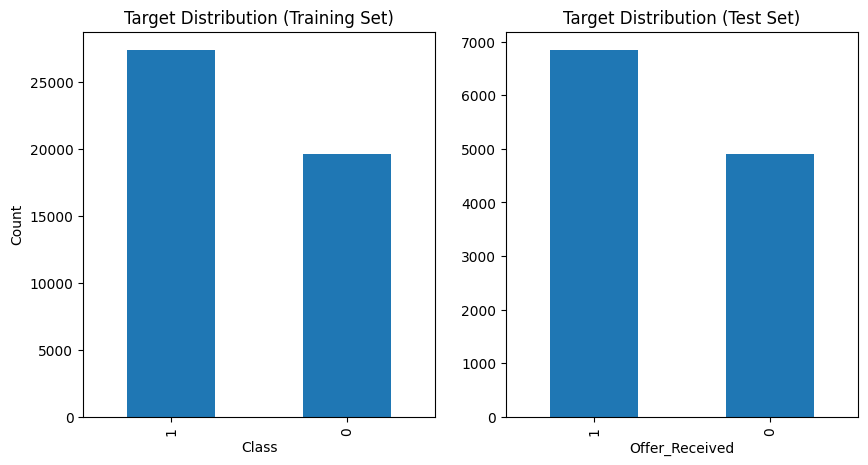

In [90]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind='bar')
plt.title('Target Distribution (Training Set)')
plt.xlabel('Class')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
y_test.value_counts().plot(kind='bar')
plt.title('Target Distribution (Test Set)')

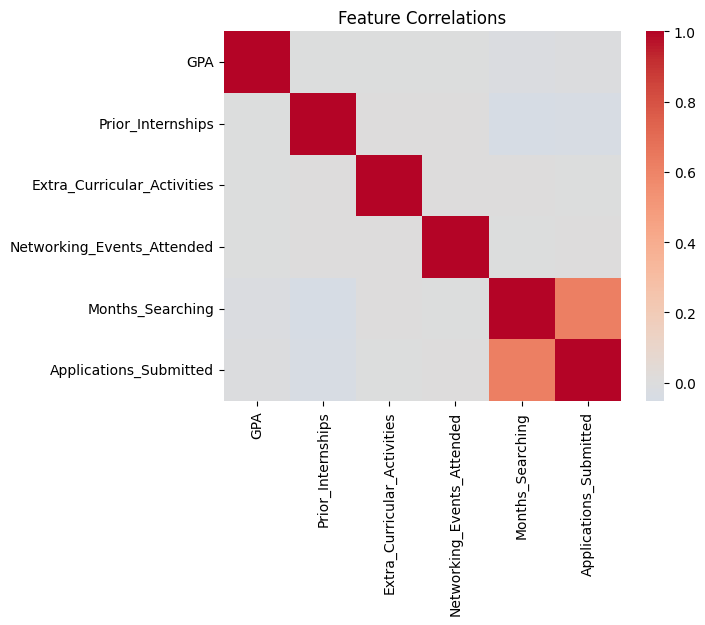

In [91]:

import seaborn as sns
train_numeric_for_plot = X_train_base[X_numeric_columns]
sns.heatmap(train_numeric_for_plot.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlations')
plt.show()

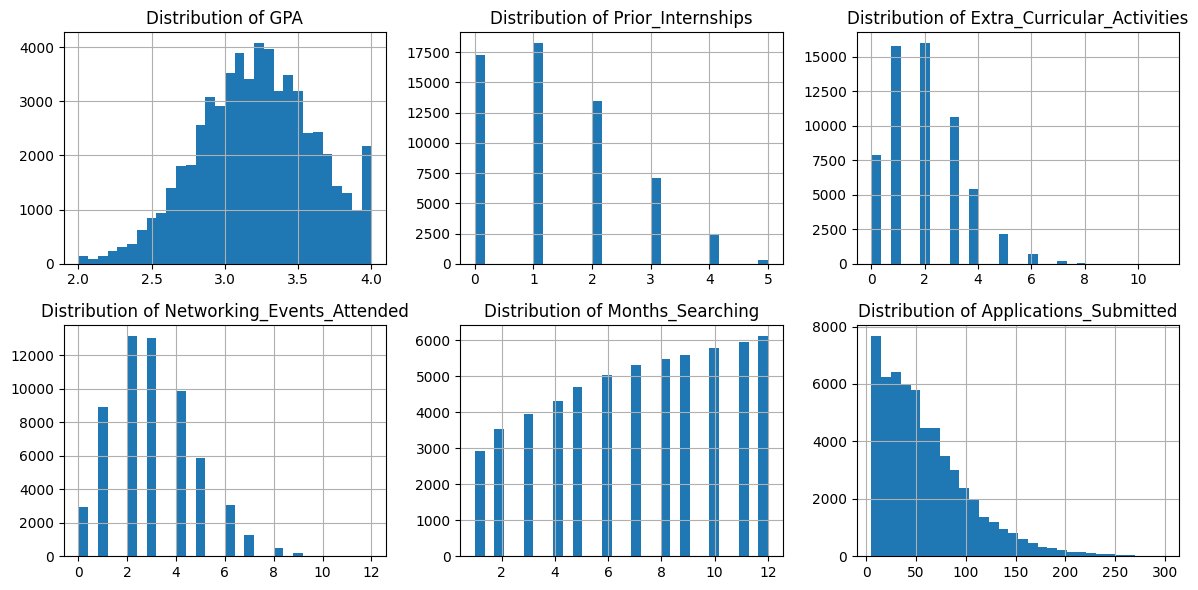

In [92]:
n_cols = 3
n_features = len(X_numeric.columns)
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, X_numeric.columns):
    X_numeric[col].hist(bins=30, ax=ax)
    ax.set_title(f'Distribution of {col}')

for ax in axes[n_features:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## BaseLine
> Created by Yueqiao on Apr 30

```
Establishes the naive baseline by predicting the most frequent class (Offer Received)
for every sample. Provides the lower-bound accuracy all models must beat.
Also imports classification_report and accuracy_score used by all subsequent sections.

Prerequisites : Preprocessing  (y_train, y_test)
Produces      : baseline_accuracy, y_pred_baseline
                imports: classification_report, accuracy_score
```

In [93]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

### Most Frequent Class

In [94]:
target_labels = {0: 'No Offer Received', 1: 'Offer Received'}
most_frequent_class = y_train.value_counts().idxmax()
print(f"Most frequent class in training set: {target_labels.get(most_frequent_class, most_frequent_class)}")
y_pred_baseline = np.full(len(y_test), most_frequent_class)
classification_rep = classification_report(y_test, y_pred_baseline)
print("Baseline Classification Report:")
print(classification_rep)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Accuracy (Most Frequent): {baseline_accuracy:.4f}")

Most frequent class in training set: Offer Received
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4909
           1       0.58      1.00      0.74      6846

    accuracy                           0.58     11755
   macro avg       0.29      0.50      0.37     11755
weighted avg       0.34      0.58      0.43     11755

Baseline Accuracy (Most Frequent): 0.5824


e:\内卷\rose\2026spring\cs415\ML\src\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\内卷\rose\2026spring\cs415\ML\src\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\内卷\rose\2026spring\cs415\ML\src\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

## Initial Models
> Created by Yueqiao on Apr 30\
> Modified by Mingkun Fu on 5/9
> Include KNN, Simple Logistic Regression


```
Trains KNN (grid search over k, weight, metric) and simple Logistic Regression
on the feature-engineered dataset. KNN serves as a non-parametric distance-based
baseline; LogReg provides an interpretable linear baseline and exposes feature weights.
Both use X_train (with polynomial features).

Prerequisites : Feature Engineering  (X_train, X_test)
                BaseLine             (classification_report, accuracy_score, y_train, y_test)
Produces      : knn, y_pred_knn, knn_accuracy
                logreg, y_pred_logreg, logreg_accuracy, feature_importance

```

### KNN Classifier

In [95]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn_grid = {
    'n_neighbors': np.arange(3, 32, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
knnCV = GridSearchCV(
    knn,
    param_grid=knn_grid,
    scoring='accuracy',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)
knnCV.fit(X_train, y_train)

print('best param:', knnCV.best_params_)
print('best valid accuracy:', round(knnCV.best_score_, 4))

best param: {'metric': 'manhattan', 'n_neighbors': np.int64(27), 'weights': 'distance'}
best valid accuracy: 0.6316


In [96]:
knn = knnCV.best_estimator_
y_pred_knn = knn.predict(X_test)
knn_classification_rep = classification_report(y_test, y_pred_knn)
print("Tuned KNN Classification Report:")
print(knn_classification_rep)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"Tuned KNN Accuracy: {knn_accuracy:.4f}")

Tuned KNN Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.46      0.51      4909
           1       0.66      0.74      0.70      6846

    accuracy                           0.62     11755
   macro avg       0.61      0.60      0.60     11755
weighted avg       0.62      0.62      0.62     11755

Tuned KNN Accuracy: 0.6230


### Simple Logistic Regression

In [97]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
logreg_classification_rep = classification_report(y_test, y_pred_logreg)
print("Logistic Regression Classification Report:")
print(logreg_classification_rep)
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
print(f"Logistic Regression Accuracy: {logreg_accuracy:.4f}")

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.46      0.52      4909
           1       0.67      0.78      0.72      6846

    accuracy                           0.64     11755
   macro avg       0.63      0.62      0.62     11755
weighted avg       0.64      0.64      0.63     11755

Logistic Regression Accuracy: 0.6432


In [98]:
coef = logreg.coef_[0]
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': coef
}).sort_values('coefficient', ascending=False)

print("Most important features (Logistic Regression):")
print(feature_importance.head(20))

Most important features (Logistic Regression):
                                              feature  coefficient
17                     Primary_Search_Platform_Indeed     0.797307
1                                   Prior_Internships     0.486083
18                   Primary_Search_Platform_LinkedIn     0.287842
0                                                 GPA     0.205957
7                          University_Rating_Top-tier     0.166493
19                           Applications_Submitted^2     0.100528
20                                              GPA^2     0.063861
13                            Major_Category_Business     0.038413
11                                       Region_South     0.030422
9                                   School_Size_Small     0.027226
2                         Extra_Curricular_Activities     0.014926
6                          University_Rating_Mid-tier     0.013115
12                                        Region_West     0.008594
8              

## Adding Regularization to Logistic regression
> Created by Mingkun Fu on 5/2
```
Applies L2 (Ridge) and L1 (Lasso) regularization to Logistic Regression via
grid search over alpha in [1e-4, 1e5]. Ridge shrinks all coefficients; Lasso
performs implicit feature selection by zeroing out weak coefficients.
Result: regularization does not significantly improve accuracy, suggesting the
model is not overfitting and the linear boundary is the bottleneck.

Prerequisites : Feature Engineering  (X_train, X_test)
                BaseLine             (classification_report, accuracy_score, y_train, y_test)
                Initial Models       (LogisticRegression already imported)
Produces      : ridge_logreg, y_pred_ridge, ridge_accuracy, ridge_feature_importance
                lasso_logreg, y_pred_lasso, lasso_accuracy, lasso_feature_importance
```

### Ridge

In [99]:
from sklearn.model_selection import GridSearchCV
import plotly.graph_objects as go

alpha_grid = np.array([0.0001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000])
grid = {'C': 1 / alpha_grid}

ridge_logreg = LogisticRegression(
    penalty='l2',
    max_iter=3000,
    random_state=0
)

ridgeCV = GridSearchCV(
    ridge_logreg,
    param_grid=grid,
    scoring='accuracy',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)
ridgeCV.fit(X_train, y_train)

best_ridge_alpha = 1 / ridgeCV.best_params_['C']

print('best alpha =', best_ridge_alpha, '  valid accuracy =', round(ridgeCV.best_score_, 4))


best alpha = 100.0   valid accuracy = 0.6405


e:\内卷\rose\2026spring\cs415\ML\src\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [100]:
ridge_results = pd.DataFrame()
ridge_results['alpha'] = np.log10(alpha_grid)
ridge_results['train accuracy'] = ridgeCV.cv_results_['mean_train_score']
ridge_results['valid accuracy'] = ridgeCV.cv_results_['mean_test_score']

fig = go.Figure()
fig.add_trace(go.Scatter(x=ridge_results['alpha'], y=ridge_results['train accuracy'], mode='lines+markers', name='train accuracy'))
fig.add_trace(go.Scatter(x=ridge_results['alpha'], y=ridge_results['valid accuracy'], mode='lines+markers', name='valid accuracy'))
fig.update_layout(title='Ridge Logistic Regression: Accuracy vs log10(alpha)', xaxis_title='log10(alpha)', yaxis_title='Accuracy')
fig.show()

ridge_logreg = ridgeCV.best_estimator_
y_pred_ridge = ridge_logreg.predict(X_test)
ridge_classification_rep = classification_report(y_test, y_pred_ridge)
print('Ridge Logistic Regression Classification Report:')
print(ridge_classification_rep)
ridge_accuracy = accuracy_score(y_test, y_pred_ridge)
print(f'Ridge Logistic Regression Accuracy: {ridge_accuracy:.4f}')

Ridge Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.45      0.52      4909
           1       0.67      0.78      0.72      6846

    accuracy                           0.64     11755
   macro avg       0.63      0.62      0.62     11755
weighted avg       0.64      0.64      0.63     11755

Ridge Logistic Regression Accuracy: 0.6442


In [101]:
ridge_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'max_abs_coefficient': np.abs(ridge_logreg.coef_).max(axis=0)
}).sort_values('max_abs_coefficient', ascending=False)

print('Most important features:')
display(ridge_feature_importance.head(20))

Most important features:


,feature,max_abs_coefficient
17,Primary_Search_Platform_Indeed,0.677883
1,Prior_Internships,0.481266
5,Applications_Submitted,0.457540
18,Primary_Search_Platform_LinkedIn,0.233909
0,GPA,0.203891
7,University_Rating_Top-tier,0.153875
19,Applications_Submitted^2,0.092548
4,Months_Searching,0.070178
20,GPA^2,0.063352
13,Major_Category_Business,0.050981


### Lasso

In [102]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import plotly.graph_objects as go

alpha_grid = np.array([0.0001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000])
grid = {'C': 1 / alpha_grid}  # LogisticRegression uses C, the inverse of alpha.

lasso_logreg = LogisticRegression(
    penalty='l1',
    solver='saga',
    max_iter=3000,
    random_state=0
)
lassoCV = GridSearchCV(
    lasso_logreg,
    param_grid=grid,
    scoring='accuracy',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)
lassoCV.fit(X_train, y_train)

best_lasso_alpha = 1 / lassoCV.best_params_['C']
print('best alpha =', best_lasso_alpha, '  valid accuracy =', round(lassoCV.best_score_, 4))

lasso_results = pd.DataFrame()
lasso_results['alpha'] = np.log10(alpha_grid)
lasso_results['train accuracy'] = lassoCV.cv_results_['mean_train_score']
lasso_results['valid accuracy'] = lassoCV.cv_results_['mean_test_score']

fig = go.Figure()
fig.add_trace(go.Scatter(x=lasso_results['alpha'], y=lasso_results['train accuracy'], mode='lines+markers', name='train accuracy'))
fig.add_trace(go.Scatter(x=lasso_results['alpha'], y=lasso_results['valid accuracy'], mode='lines+markers', name='valid accuracy'))
fig.update_layout(title='Lasso Logistic Regression: Accuracy vs log10(alpha)', xaxis_title='log10(alpha)', yaxis_title='Accuracy')
fig.show()

lasso_logreg = lassoCV.best_estimator_
y_pred_lasso = lasso_logreg.predict(X_test)
lasso_classification_rep = classification_report(y_test, y_pred_lasso)
print('Lasso Logistic Regression Classification Report:')
print(lasso_classification_rep)
lasso_accuracy = accuracy_score(y_test, y_pred_lasso)
print(f'Lasso Logistic Regression Accuracy: {lasso_accuracy:.4f}')

lasso_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'max_abs_coefficient': np.abs(lasso_logreg.coef_).max(axis=0)
}).sort_values('max_abs_coefficient', ascending=False)

print('Most important features:')
display(lasso_feature_importance.head(20))

best alpha = 100.0   valid accuracy = 0.6402


e:\内卷\rose\2026spring\cs415\ML\src\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\内卷\rose\2026spring\cs415\ML\src\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Lasso Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.45      0.51      4909
           1       0.66      0.79      0.72      6846

    accuracy                           0.64     11755
   macro avg       0.63      0.62      0.62     11755
weighted avg       0.64      0.64      0.63     11755

Lasso Logistic Regression Accuracy: 0.6449
Most important features:


,feature,max_abs_coefficient
17,Primary_Search_Platform_Indeed,0.589633
1,Prior_Internships,0.479426
5,Applications_Submitted,0.413366
0,GPA,0.195562
18,Primary_Search_Platform_LinkedIn,0.176717
7,University_Rating_Top-tier,0.090017
4,Months_Searching,0.082523
19,Applications_Submitted^2,0.082150
20,GPA^2,0.057012
21,GPA Prior_Internships,0.006114


Adding ridge and lasso regularization to logistic regression model gives similar test accuracy as the simple logistic regression, this means stronger regularization does not improve predictive performance for this dataset.


## Random Forest classifier

```
Trains a Random Forest using X_train_base (no feature engineering — RF captures
interactions internally via splits). Runs a coarse grid search over n_estimators
and max_depth, then a fine-tuned search around the best region. Two-stage search
balances compute cost with hyperparameter precision.

Prerequisites : Preprocessing  (X_train_base, X_test_base, y_train, y_test)
                BaseLine       (classification_report, accuracy_score)
Produces      : new_rf, y_pred_new_rf, new_rf_accuracy
```

> Created by Mingkun Fu on 5/3\
> Modified by Mingkun Fu on 5/9

In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

num_trees = np.arange(1,501,50)
depth = np.arange(1,26,5)

grid = {'n_estimators': num_trees, 'max_depth': depth}
rf = RandomForestClassifier(random_state=0,n_jobs=1)
rfCV = GridSearchCV(rf,param_grid=grid,scoring='accuracy',return_train_score=True,n_jobs=-1)
rfCV.fit(X_train_base, y_train)

print('best param:',rfCV.best_params_)
print('best valid accuracy:',rfCV.best_score_)

best param: {'max_depth': np.int64(11), 'n_estimators': np.int64(451)}
best valid accuracy: 0.6505307296471307


In [104]:
rf = rfCV.best_estimator_
y_pred_rf = rf.predict(X_test_base)
print('Random Forest Classification Report:')
print(classification_report(y_test, y_pred_rf))
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {rf_accuracy:.4f}')

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.46      0.52      4909
           1       0.67      0.78      0.72      6846

    accuracy                           0.65     11755
   macro avg       0.64      0.62      0.62     11755
weighted avg       0.64      0.65      0.64     11755

Random Forest Accuracy: 0.6471


In [105]:
import plotly.express as px
result = rfCV.cv_results_["mean_test_score"].reshape(num_trees.size, depth.size, order='F')
fig = px.imshow(result)
fig.show()

A closer grid search:

In [ ]:
new_num_tree = np.arange(420,481,1)
new_depth = np.arange(9,12,1)
new_grid = {'n_estimators': new_num_tree, 'max_depth': new_depth}

new_rf = RandomForestClassifier(random_state=0,n_jobs=1)
new_rfCV = GridSearchCV(new_rf,param_grid=new_grid,scoring='accuracy',return_train_score=True,n_jobs=-1)
new_rfCV.fit(X_train_base, y_train)

print('best param:', new_rfCV.best_params_)
print('best valid accuracy:', new_rfCV.best_score_)


best param: {'max_depth': np.int64(11), 'n_estimators': np.int64(477)}
best valid accuracy: 0.6510411846712814


In [129]:
new_rf = new_rfCV.best_estimator_
y_pred_new_rf = new_rf.predict(X_test_base)
print('Fine-tuned Random Forest Classification Report:')
print(classification_report(y_test, y_pred_new_rf))
new_rf_accuracy = accuracy_score(y_test, y_pred_new_rf)
print(f'Fine-tuned Random Forest Accuracy: {new_rf_accuracy:.4f}')


Fine-tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.46      0.52      4909
           1       0.67      0.78      0.72      6846

    accuracy                           0.65     11755
   macro avg       0.63      0.62      0.62     11755
weighted avg       0.64      0.65      0.64     11755

Fine-tuned Random Forest Accuracy: 0.6470


In [130]:
new_result = new_rfCV.cv_results_["mean_test_score"].reshape(new_num_tree.size, new_depth.size, order='F')
fig = px.imshow(new_result)
fig.show()

## Gradient Boosting model
>Created by Yueqiao Wang on 5/7
```

Trains a Gradient Boosting Classifier using X_train_base. Grid searches over
learning_rate, n_estimators, and max_depth, followed by a fine-tuned search.
GBT builds trees sequentially to correct previous errors, typically outperforming
Random Forest on structured tabular data at the cost of longer training time.

Prerequisites : Preprocessing  (X_train_base, X_test_base, y_train, y_test)
                BaseLine       (classification_report, accuracy_score)
Produces      : new_gbt, y_pred_new_gbt, new_gbt_accuracy
```

In [109]:
from sklearn.ensemble import GradientBoostingClassifier

gbt_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [1, 2, 3, 5, 7]
}

gbt = GradientBoostingClassifier(random_state=0)
gbtCV = GridSearchCV(
    gbt,
    param_grid=gbt_grid,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)
gbtCV.fit(X_train_base, y_train)

print('best param:', gbtCV.best_params_)
print('best valid accuracy:', gbtCV.best_score_)

best param: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
best valid accuracy: 0.6521471354993043


In [110]:
gbt = gbtCV.best_estimator_
y_pred_gbt = gbt.predict(X_test_base)
print('Gradient Boosting Classification Report:')
print(classification_report(y_test, y_pred_gbt))
gbt_accuracy = accuracy_score(y_test, y_pred_gbt)
print(f'Gradient Boosting Accuracy: {gbt_accuracy:.4f}')

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.47      0.53      4909
           1       0.67      0.78      0.72      6846

    accuracy                           0.65     11755
   macro avg       0.64      0.63      0.63     11755
weighted avg       0.64      0.65      0.64     11755

Gradient Boosting Accuracy: 0.6511


In [133]:
from sklearn.ensemble import GradientBoostingClassifier
new_gbt_grid = {
    'learning_rate': [0.05],
    'n_estimators': np.arange(80, 121, 1),
    'max_depth': [4,5,6]
}

new_gbt = GradientBoostingClassifier(random_state=0)
new_gbtCV = GridSearchCV(
    new_gbt,
    param_grid=new_gbt_grid,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)
new_gbtCV.fit(X_train_base, y_train)

print('best param:', new_gbtCV.best_params_)
print('best valid accuracy:', new_gbtCV.best_score_)


best param: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': np.int64(87)}
best valid accuracy: 0.6522960196282959


In [134]:
new_gbt = new_gbtCV.best_estimator_
y_pred_new_gbt = new_gbt.predict(X_test_base)
print('Fine-tuned Gradient Boosting Classification Report:')
print(classification_report(y_test, y_pred_new_gbt))
new_gbt_accuracy = accuracy_score(y_test, y_pred_new_gbt)
print(f'Fine-tuned Gradient Boosting Accuracy: {new_gbt_accuracy:.4f}')

Fine-tuned Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.47      0.53      4909
           1       0.67      0.78      0.72      6846

    accuracy                           0.65     11755
   macro avg       0.64      0.63      0.63     11755
weighted avg       0.65      0.65      0.64     11755

Fine-tuned Gradient Boosting Accuracy: 0.6517


In [135]:
import plotly.express as px
new_gbt_results = pd.DataFrame(new_gbtCV.cv_results_)
new_gbt_results['learning_rate'] = new_gbt_results['param_learning_rate'].astype(float)
new_gbt_results['n_estimators'] = new_gbt_results['param_n_estimators'].astype(int)
new_gbt_results['max_depth'] = new_gbt_results['param_max_depth'].astype(int)

fig = px.density_heatmap(
    new_gbt_results,
    x='n_estimators',
    y='max_depth',
    z='mean_test_score',
    facet_col='learning_rate',
    color_continuous_scale='Viridis',
    title='Fine-tuned Gradient Boosting validation accuracy'
)
fig.update_layout(xaxis_title='n_estimators', yaxis_title='max_depth')
fig.show()

## Support Vector Machine
> Created by Yueqiao on May 14

Standard SVC with non-linear kernels like RBF requires computing kernel values between every pair of training samples, giving O(n?) to O(n?) complexity
Although LinearSVC draws a linear decision boundary, it is trained on our feature-engineered dataset containing polynomial and interaction terms, which allows it to capture non-linear relationships between the original features while remaining computationally efficient.

```
Trains a LinearSVC wrapped in CalibratedClassifierCV (to enable predict_proba)
on the feature-engineered dataset X_train. Standard SVC with RBF kernel is O(n??n?)
and impractical for 80,000 samples; LinearSVC reduces this to O(n ? features).
Although the decision boundary is linear, training on polynomial features allows
it to capture non-linear relationships in the original feature space.
Grid searches over regularization strength C.

Prerequisites : Feature Engineering  (X_train, X_test)
                BaseLine             (classification_report, accuracy_score, y_train, y_test)
Produces      : svm, y_pred_svm, svm_accuracy
```

In [140]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV

# Ask claude for this
# LinearSVC does not support predict_proba natively,
# so we wrap it with CalibratedClassifierCV
svm_grid = {
    'estimator__C': [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 1000],
    'estimator__loss': ['hinge', 'squared_hinge'] 
}

base_svm = CalibratedClassifierCV(LinearSVC(max_iter=5000, random_state=0))

print('Starting SVM Grid Search...')
print('Total combinations to try:', len(svm_grid['estimator__C']) * len(svm_grid['estimator__loss']))
print('The dataset has', X_train.shape[1], 'features and ', X_train.shape[0], 'samples.')

svmCV = GridSearchCV(
    base_svm,
    param_grid=svm_grid,
    scoring='accuracy',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)
svmCV.fit(X_train, y_train)

print('best param:', svmCV.best_params_)
print('best valid accuracy:', round(svmCV.best_score_, 4))

Starting SVM Grid Search...
Total combinations to try: 22
The dataset has 26 features and  47017 samples.
best param: {'estimator__C': 0.001, 'estimator__loss': 'squared_hinge'}
best valid accuracy: 0.6405


In [141]:
svm = svmCV.best_estimator_
y_pred_svm = svm.predict(X_test)

print('SVM Classification Report:')
print(classification_report(y_test, y_pred_svm))
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f'SVM Accuracy: {svm_accuracy:.4f}')

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.45      0.52      4909
           1       0.67      0.78      0.72      6846

    accuracy                           0.65     11755
   macro avg       0.63      0.62      0.62     11755
weighted avg       0.64      0.65      0.63     11755

SVM Accuracy: 0.6451


In [142]:
import plotly.graph_objects as go
import numpy as np

svm_cv_results = pd.DataFrame(svmCV.cv_results_)
C_vals = [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 1000]

fig = go.Figure()

for loss_type in ['hinge', 'squared_hinge']:
    mask = svm_cv_results['param_estimator__loss'] == loss_type
    subset = svm_cv_results[mask].copy()
    subset['log10_C'] = np.log10(subset['param_estimator__C'].astype(float)).round(2)
    subset = subset.sort_values('log10_C')

    fig.add_trace(go.Scatter(
        x=subset['log10_C'],
        y=subset['mean_train_score'],
        mode='lines+markers',
        name=f'train ({loss_type})',
        line=dict(dash='dash')
    ))
    fig.add_trace(go.Scatter(
        x=subset['log10_C'],
        y=subset['mean_test_score'],
        mode='lines+markers',
        name=f'valid ({loss_type})'
    ))

fig.update_layout(
    title='LinearSVC: Accuracy vs log10(C) by loss function',
    xaxis_title='log10(C)',
    yaxis_title='Accuracy'
)
fig.show()

## Decision Tree Classifier
> Created by Yueqiao on May 14
```
Trains a Decision Tree on X_train_base. Unlike ensemble methods, a single decision
tree is fully interpretable — the tree structure can be visualized to show the exact
decision rules the model learned. Grid searches over max_depth, min_samples_split,
and min_samples_leaf to control overfitting. The tree is visualized at depth=3
for readability; feature importances are plotted for comparison with other models.

Prerequisites : Preprocessing  (X_train_base, X_test_base, y_train, y_test)
                BaseLine       (classification_report, accuracy_score)
Produces      : dt, y_pred_dt, dt_accuracy, dt_importances
```


In [143]:
from sklearn.tree import DecisionTreeClassifier

dt_grid = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10, 15, None],
    'min_samples_split': [2, 10, 50],
    'min_samples_leaf': [1, 5, 20]
}

dt = DecisionTreeClassifier(random_state=0)
dtCV = GridSearchCV(
    dt,
    param_grid=dt_grid,
    scoring='accuracy',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)
dtCV.fit(X_train_base, y_train)

print('best param:', dtCV.best_params_)
print('best valid accuracy:', round(dtCV.best_score_, 4))

best param: {'max_depth': 6, 'min_samples_leaf': 20, 'min_samples_split': 2}
best valid accuracy: 0.649


In [144]:
dt = dtCV.best_estimator_
y_pred_dt = dt.predict(X_test_base)

print('Decision Tree Classification Report:')
print(classification_report(y_test, y_pred_dt))
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree Accuracy: {dt_accuracy:.4f}')

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.49      0.54      4909
           1       0.67      0.76      0.71      6846

    accuracy                           0.65     11755
   macro avg       0.63      0.62      0.63     11755
weighted avg       0.64      0.65      0.64     11755

Decision Tree Accuracy: 0.6467


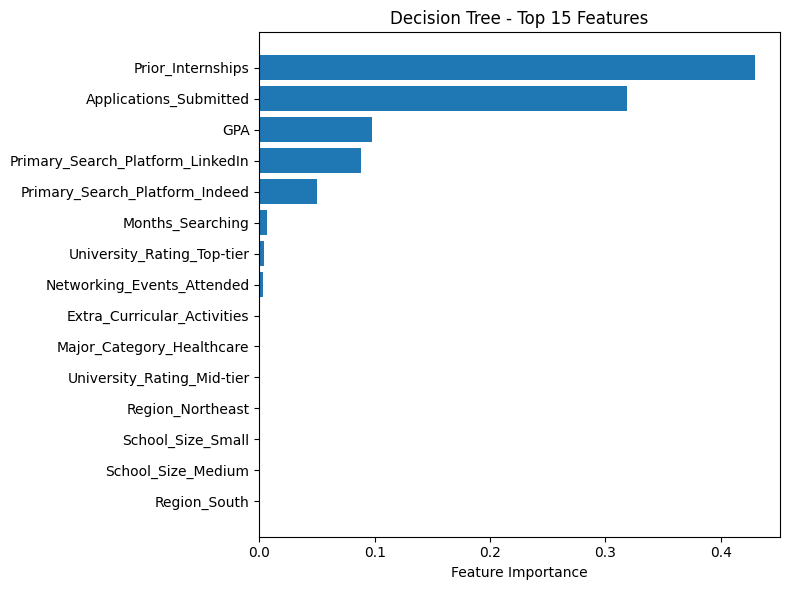

In [145]:
# Feature importance
dt_importances = pd.DataFrame({
    'feature': X_test_base.columns,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(dt_importances['feature'][::-1], dt_importances['importance'][::-1])
plt.xlabel('Feature Importance')
plt.title('Decision Tree - Top 15 Features')
plt.tight_layout()
plt.show()

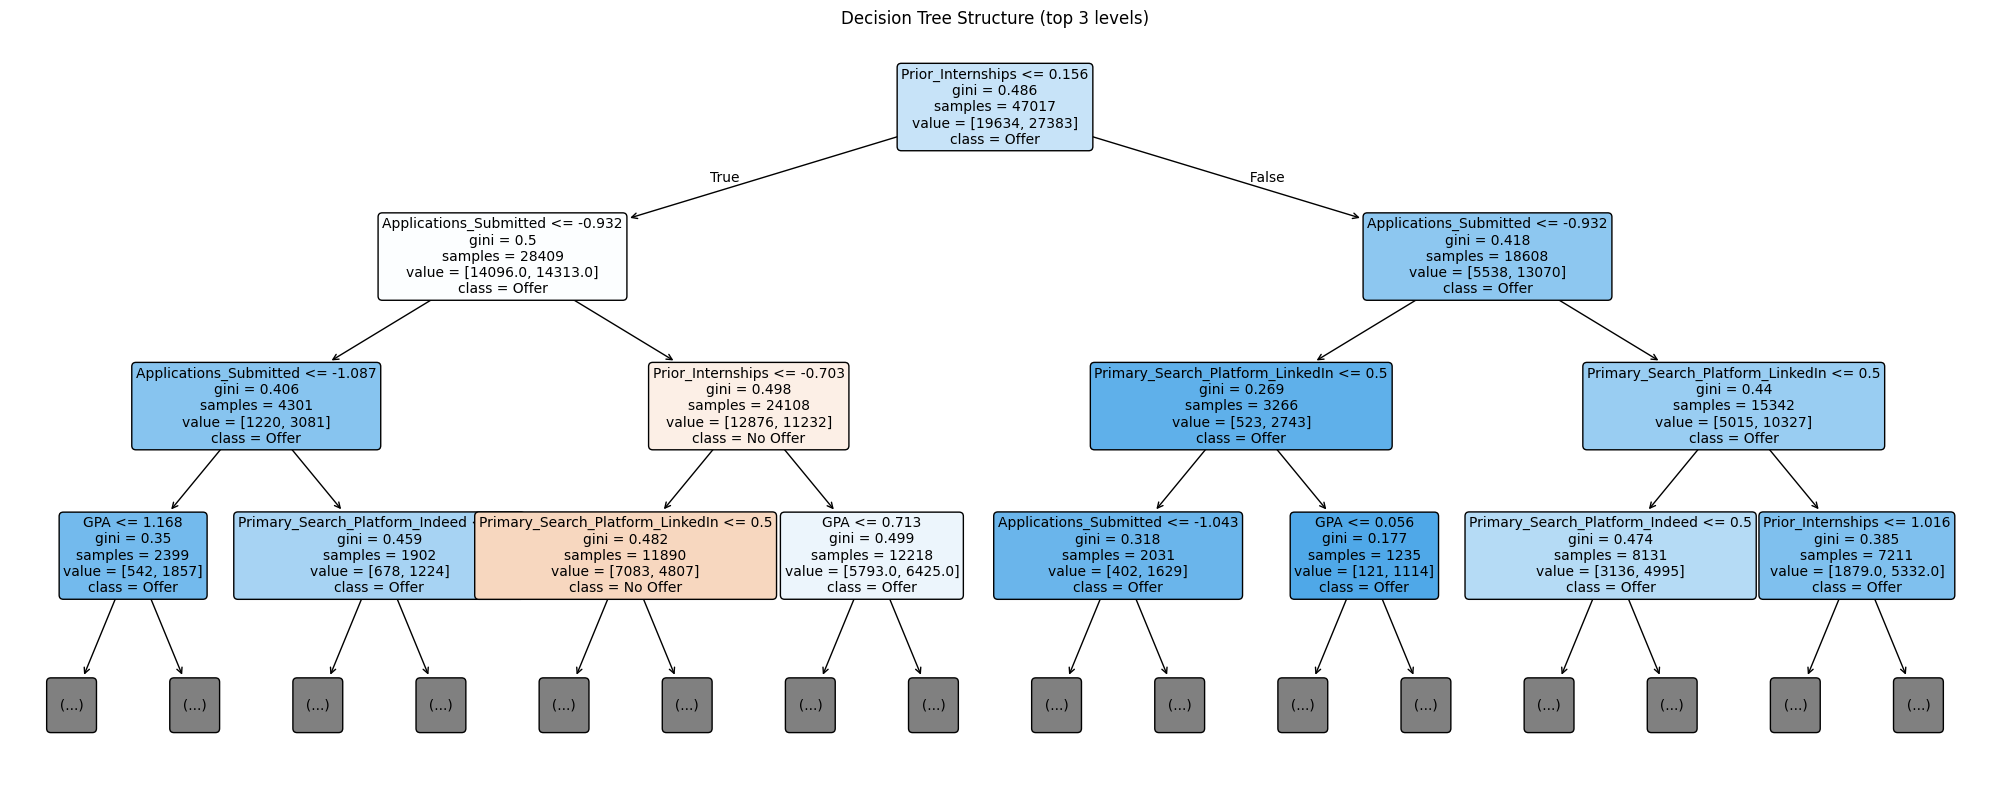

In [146]:
# Visualize the tree (capped at depth=3 for readability)
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    max_depth=3,
    feature_names=X_test_base.columns,
    class_names=['No Offer', 'Offer'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree Structure (top 3 levels)')
plt.tight_layout()
plt.show()

In [147]:
# depth vs accuracy (train/valid) — check overfitting
depth_results = pd.DataFrame(dtCV.cv_results_)
depth_only = depth_results[
    (depth_results['param_min_samples_split'] == dtCV.best_params_['min_samples_split']) &
    (depth_results['param_min_samples_leaf']  == dtCV.best_params_['min_samples_leaf'])
].copy()

depth_vals = depth_only['param_max_depth'].astype(str)

fig = go.Figure()
fig.add_trace(go.Scatter(x=depth_vals, y=depth_only['mean_train_score'],
                         mode='lines+markers', name='train accuracy'))
fig.add_trace(go.Scatter(x=depth_vals, y=depth_only['mean_test_score'],
                         mode='lines+markers', name='valid accuracy'))
fig.update_layout(title='Decision Tree: Accuracy vs max_depth',
                  xaxis_title='max_depth', yaxis_title='Accuracy')
fig.show()

## Model Comparison
> Created by Yueqiao Wang on May 14

Collects the test-set accuracy of every model trained in this notebook
(Baseline → KNN → LogReg → Ridge → Lasso → Decision Tree → LinearSVC
→ Random Forest → Gradient Boosting) into a single ranked summary table
and bar chart. Then performs individual-level prediction analysis using
the two best models (fine-tuned RF and fine-tuned GBT) to identify the
most confident correct predictions and the most costly mistakes.
Finally compares feature importances across tree-based models.

```
Prerequisites : BaseLine, Initial Models, Adding Regularization,
                Random Forest, Gradient Boosting, SVM, Decision Tree
                (all *_accuracy and y_pred_* variables must exist)
Produces      : comparison_df            — ranked accuracy table
                best_correct / worst     — individual-level analysis
                fi_df                    — cross-model feature importances
```

In [148]:
# Builds a ranked DataFrame of every model's test-set accuracy.
# 'Dataset' column records which feature set was used:
#   Base = scaled original features (19 cols)
#   FE   = Base + greedy-selected polynomial / interaction terms (32 cols)
# Tree-based models use Base because they capture interactions internally;
# linear / distance-based models benefit from the extra FE columns.

comparison_data = {
    'Model': [
        'Baseline (Most Frequent)',
        'KNN (tuned)',
        'Logistic Regression',
        'Ridge Logistic Regression',
        'Lasso Logistic Regression',
        'Decision Tree (tuned)',
        'LinearSVC',
        'Random Forest (tuned)',
        'Gradient Boosting (tuned)',
    ],
    'Feature Set': [
        '—',
        'FE',
        'FE',
        'FE',
        'FE',
        'Base',
        'FE',
        'Base',
        'Base',
    ],
    'Test Accuracy': [
        baseline_accuracy,
        knn_accuracy,
        logreg_accuracy,
        ridge_accuracy,
        lasso_accuracy,
        dt_accuracy,
        svm_accuracy,
        new_rf_accuracy,
        new_gbt_accuracy,
    ]
}

comparison_df = (
    pd.DataFrame(comparison_data)
    .sort_values('Test Accuracy', ascending=False)
    .reset_index(drop=True)
)
comparison_df.index = comparison_df.index + 1   # 1-indexed rank
comparison_df.index.name = 'Rank'

# Keep a numeric copy for plotting before formatting
comparison_df_numeric = comparison_df.copy()
comparison_df['Test Accuracy'] = comparison_df['Test Accuracy'].map('{:.4f}'.format)
display(comparison_df)


,Model,Feature Set,Test Accuracy
Rank,,,
1,Gradient Boosting (tuned),Base,0.6517
2,Random Forest (tuned),Base,0.6470
3,Decision Tree (tuned),Base,0.6467
4,LinearSVC,FE,0.6451
5,Lasso Logistic Regression,FE,0.6449
6,Ridge Logistic Regression,FE,0.6442
7,Logistic Regression,FE,0.6432
8,KNN (tuned),FE,0.6230
9,Baseline (Most Frequent),—,0.5824


In [149]:
# Horizontal bar chart — models sorted descending by test accuracy.
# Baseline is highlighted in red so it is easy to read the improvement gap.
# Models are color-coded by feature set (Base vs FE).

import plotly.graph_objects as go

plot_df = comparison_df_numeric.sort_values('Test Accuracy')   # ascending for barh

colors = []
for _, row in plot_df.iterrows():
    if row['Model'] == 'Baseline (Most Frequent)':
        colors.append('#d62728')   # red  — baseline reference
    elif row['Feature Set'] == 'FE':
        colors.append('#1f77b4')   # blue — feature-engineered models
    else:
        colors.append('#2ca02c')   # green — tree-based / base models

fig = go.Figure(go.Bar(
    x=plot_df['Test Accuracy'],
    y=plot_df['Model'],
    orientation='h',
    marker_color=colors,
    text=plot_df['Test Accuracy'].map('{:.4f}'.format),
    textposition='outside'
))
fig.update_layout(
    title='Test Accuracy by Model (red = baseline, blue = FE, green = Base)',
    xaxis=dict(title='Test Accuracy', range=[0, 1.05]),
    yaxis_title='Model',
    height=500,
    margin=dict(l=220)
)
fig.show()


### Feature Importance Comparison (Tree Models)

In [151]:

feature_names = list(X_test_base.columns)

fi_df = pd.DataFrame({
    'Feature'        : feature_names,
    'Decision Tree'  : dt.feature_importances_,
    'Random Forest'  : new_rf.feature_importances_,
    'Gradient Boost' : new_gbt.feature_importances_,
})

# Rank by GBT importance and keep top 10
fi_df = fi_df.sort_values('Gradient Boost', ascending=False).head(10)

fi_melted = fi_df.melt(
    id_vars='Feature',
    value_vars=['Decision Tree', 'Random Forest', 'Gradient Boost'],
    var_name='Model',
    value_name='Importance'
)

fig = px.bar(
    fi_melted,
    x='Importance',
    y='Feature',
    color='Model',
    barmode='group',
    orientation='h',
    title='Feature Importance — Top 10 (ranked by Gradient Boosting)',
    height=520
)
fig.update_layout(yaxis=dict(categoryorder='total ascending'))
fig.show()

print('Top-10 features by Gradient Boosting importance:')
display(fi_df.reset_index(drop=True))

# Rank by Random Forest importance and keep top 10
fi_df = fi_df.sort_values('Random Forest', ascending=False).head(10)

fi_melted = fi_df.melt(
    id_vars='Feature',
    value_vars=['Decision Tree', 'Random Forest', 'Gradient Boost'],
    var_name='Model',
    value_name='Importance'
)

fig = px.bar(
    fi_melted,
    x='Importance',
    y='Feature',
    color='Model',
    barmode='group',
    orientation='h',
    title='Feature Importance — Top 10 (ranked by Random Forest)',
    height=520
)
fig.update_layout(yaxis=dict(categoryorder='total ascending'))
fig.show()

print('Top-10 features by Random Forest importance:')
display(fi_df.reset_index(drop=True))

# Rank by Decision Tree importance and keep top 10
fi_df = fi_df.sort_values('Decision Tree', ascending=False).head(10)

fi_melted = fi_df.melt(
    id_vars='Feature',
    value_vars=['Decision Tree', 'Random Forest', 'Gradient Boost'],
    var_name='Model',
    value_name='Importance'
)

fig = px.bar(
    fi_melted,
    x='Importance',
    y='Feature',
    color='Model',
    barmode='group',
    orientation='h',
    title='Feature Importance — Top 10 (ranked by Decision Tree)',
    height=520
)
fig.update_layout(yaxis=dict(categoryorder='total ascending'))
fig.show()

print('Top-10 features by Decision Tree importance:')
display(fi_df.reset_index(drop=True))




Top-10 features by Gradient Boosting importance:


,Feature,Decision Tree,Random Forest,Gradient Boost
0,Prior_Internships,0.430043,0.248938,0.383261
1,Applications_Submitted,0.318672,0.213375,0.288816
2,GPA,0.097910,0.143372,0.120530
3,Primary_Search_Platform_LinkedIn,0.088219,0.043572,0.082436
4,Primary_Search_Platform_Indeed,0.049820,0.025325,0.066413
5,Months_Searching,0.006980,0.106548,0.020572
6,University_Rating_Top-tier,0.004152,0.015209,0.011861
7,Networking_Events_Attended,0.003074,0.051118,0.006919
8,Extra_Curricular_Activities,0.000566,0.044857,0.006740
9,Region_Northeast,0.000000,0.011702,0.002553


Top-10 features by Random Forest importance:


,Feature,Decision Tree,Random Forest,Gradient Boost
0,Prior_Internships,0.430043,0.248938,0.383261
1,Applications_Submitted,0.318672,0.213375,0.288816
2,GPA,0.097910,0.143372,0.120530
3,Months_Searching,0.006980,0.106548,0.020572
4,Networking_Events_Attended,0.003074,0.051118,0.006919
5,Extra_Curricular_Activities,0.000566,0.044857,0.006740
6,Primary_Search_Platform_LinkedIn,0.088219,0.043572,0.082436
7,Primary_Search_Platform_Indeed,0.049820,0.025325,0.066413
8,University_Rating_Top-tier,0.004152,0.015209,0.011861
9,Region_Northeast,0.000000,0.011702,0.002553


Top-10 features by Decision Tree importance:


,Feature,Decision Tree,Random Forest,Gradient Boost
0,Prior_Internships,0.430043,0.248938,0.383261
1,Applications_Submitted,0.318672,0.213375,0.288816
2,GPA,0.097910,0.143372,0.120530
3,Primary_Search_Platform_LinkedIn,0.088219,0.043572,0.082436
4,Primary_Search_Platform_Indeed,0.049820,0.025325,0.066413
5,Months_Searching,0.006980,0.106548,0.020572
6,University_Rating_Top-tier,0.004152,0.015209,0.011861
7,Networking_Events_Attended,0.003074,0.051118,0.006919
8,Extra_Curricular_Activities,0.000566,0.044857,0.006740
9,Region_Northeast,0.000000,0.011702,0.002553


### Confusion Matrix — Best vs Interpretable Model

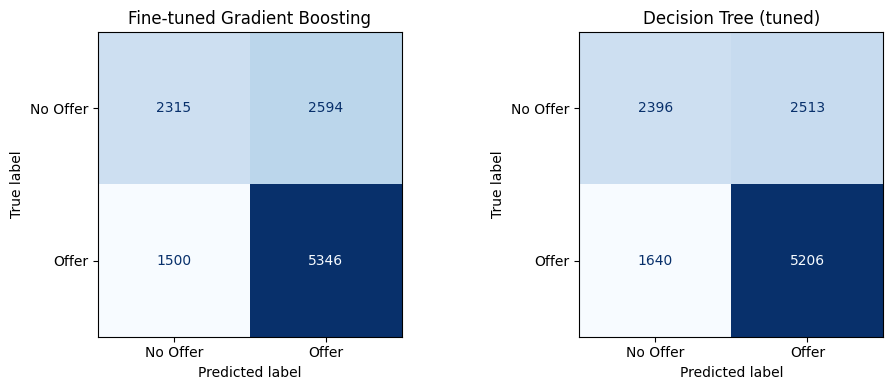

In [152]:
# Side-by-side confusion matrices for GBT (best accuracy) and
# Decision Tree (most interpretable). Confusion matrices show not just
# overall accuracy but *which class* each model struggles with.

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
y_test_reset = y_test.reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_new_gbt, y_pred_dt],
    ['Fine-tuned Gradient Boosting', 'Decision Tree (tuned)']
):
    cm = confusion_matrix(y_test_reset, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Offer', 'Offer']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.tight_layout()
plt.show()


## Individual Prediction Analysis

> Created by Yueqiao Wang on May 14

In [153]:
# Helper: given a fitted model, test features X, true labels y,
# and predicted labels y_pred, return the best and worst individual records.
# 'best'  = correct prediction with highest confidence (prob of true class)
# 'worst' = wrong   prediction with highest confidence (most costly mistake)

import numpy as np

def analyze_predictions(model_name, model, X_test_df, y_test_series, y_pred_arr):
    proba = model.predict_proba(X_test_df)          # shape (n_samples, 2)
    true_labels = y_test_series.values

    # confidence = predicted probability for the TRUE class
    confidence = proba[np.arange(len(true_labels)), true_labels.astype(int)]

    correct_mask   = (y_pred_arr == true_labels)
    incorrect_mask = ~correct_mask

    best_idx  = np.where(correct_mask)[0][np.argmax(confidence[correct_mask])]
    worst_idx = np.where(incorrect_mask)[0][np.argmax(confidence[incorrect_mask])]

    label_map = {0: 'No Offer', 1: 'Offer Received'}

    print(f'=== {model_name} ===')
    print(f'\n  BEST prediction  (index {best_idx})')
    print(f'    True label      : {label_map[true_labels[best_idx]]}')
    print(f'    Predicted label : {label_map[y_pred_arr[best_idx]]}')
    print(f'    Confidence      : {confidence[best_idx]:.4f}')
    print(f'    Key features    :')
    display(X_test_df.iloc[best_idx][list(X_numeric_columns)].to_frame().T)

    print(f'\n  WORST prediction (index {worst_idx})')
    print(f'    True label      : {label_map[true_labels[worst_idx]]}')
    print(f'    Predicted label : {label_map[y_pred_arr[worst_idx]]}')
    print(f'    Confidence      : {confidence[worst_idx]:.4f}')
    print(f'    Key features    :')
    display(X_test_df.iloc[worst_idx][list(X_numeric_columns)].to_frame().T)
    print()


In [154]:
analyze_predictions(
    'Fine-tuned Gradient Boosting',
    new_gbt, X_test_base, y_test_reset, y_pred_new_gbt
)

analyze_predictions(
    'Fine-tuned Random Forest',
    new_rf, X_test_base, y_test_reset, y_pred_new_rf
)

=== Fine-tuned Gradient Boosting ===

  BEST prediction  (index 1450)
    True label      : Offer Received
    Predicted label : Offer Received
    Confidence      : 0.9625
    Key features    :


,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted
1450,1.104724,2.305094,-0.00646,-0.574276,-1.861128,-1.12053



  WORST prediction (index 1513)
    True label      : Offer Received
    Predicted label : No Offer
    Confidence      : 0.4999
    Key features    :


,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted
1513,-0.083206,0.58619,0.701502,-0.574276,1.151184,0.010597



=== Fine-tuned Random Forest ===

  BEST prediction  (index 4328)
    True label      : Offer Received
    Predicted label : Offer Received
    Confidence      : 0.9715
    Key features    :


,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted
4328,0.118995,2.305094,-0.714421,-0.574276,-1.861128,-1.187067



  WORST prediction (index 9756)
    True label      : No Offer
    Predicted label : Offer Received
    Confidence      : 0.5000
    Key features    :


,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted
9756,0.725598,-0.273262,-0.00646,1.730917,1.151184,-0.033761


## What features are important among the 2nd interview candidates?

Among all the students who reached a 2nd round interview, the strong predictor of receiving an offer are prior internship experience,number of application submitted, and GPA. Both the RF, DT and GBT models agree this conclusion. Search platforms also show moderate importance, especially LinkedIn and Indeed. Other features such as months searching, networking events, extracurricular activities, university tier, and region have weaker or less consistent effects.